In [1]:
#loading metacells of rna and atac data
import anndata
from anndata import AnnData
import pandas as pd
import scanpy as sc

sc_rna = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/SEAcells/SEACell_summarized_annot_RNA.h5ad")
sc_atac = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/SEAcells/SEACell_summarized_annot_ATAC.h5ad")
rna_mapping = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/SEAcells/RNA_SEACell_mapping.csv", sep='\t', index_col=0)

gene_peaks_10kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_10kb.csv")
gene_peaks_20kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_20kb.csv")
gene_peaks_50kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_50kb.csv")
gene_peaks_100kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_100kb.csv")

In [2]:
print(sc_atac.X.shape)
print(sc_rna.X.shape)

(1260, 640834)
(1260, 19380)


In [4]:
#function for normalizing the aggregated data by total counts per SEACell to get relative accessibility/expression values (compositional normalization)

def compositional_normalization(data):
    import pandas as pd
    import scipy.sparse as sp
    
    # extract to dense DataFrame
    if sp.issparse(data.X):
        df = pd.DataFrame(data.X.toarray(), index=data.obs_names, columns=data.var_names)
    else:
        df = pd.DataFrame(data.X, index=data.obs_names, columns=data.var_names)
    
    # normalize
    row_sums = df.sum(axis=1)
    if (row_sums == 0).any():
        print(f"Warning: {(row_sums == 0).sum()} metacells with zero counts.")
    df_norm = df.div(row_sums, axis=0)
    
    # put back into AnnData, preserving obs/var metadata
    data_norm = data.copy()
    data_norm.X = df_norm.values
    return data_norm

In [5]:
#normalize the raw counts of both datasets by total counts per SEACell to get relative accessibility/expression values (compositional normalization)
sc_rna_norm = compositional_normalization(sc_rna)
sc_atac_norm = compositional_normalization(sc_atac)

In [6]:
#check dimensions of the data
print(sc_atac_norm.X.shape)
print(sc_rna_norm.X.shape)

print(sc_atac_norm.obs_names)
print(sc_rna_norm.obs_names)

(1260, 640834)
(1260, 19380)
Index(['SEACell-1201', 'SEACell-667', 'SEACell-259', 'SEACell-541',
       'SEACell-503', 'SEACell-109', 'SEACell-478', 'SEACell-241',
       'SEACell-1045', 'SEACell-624',
       ...
       'SEACell-742', 'SEACell-1009', 'SEACell-941', 'SEACell-294',
       'SEACell-1224', 'SEACell-983', 'SEACell-1055', 'SEACell-1119',
       'SEACell-543', 'SEACell-665'],
      dtype='object', length=1260)
Index(['SEACell-1201', 'SEACell-667', 'SEACell-259', 'SEACell-541',
       'SEACell-503', 'SEACell-109', 'SEACell-478', 'SEACell-241',
       'SEACell-1045', 'SEACell-624',
       ...
       'SEACell-742', 'SEACell-1009', 'SEACell-941', 'SEACell-294',
       'SEACell-1224', 'SEACell-983', 'SEACell-1055', 'SEACell-1119',
       'SEACell-543', 'SEACell-665'],
      dtype='object', length=1260)


In [7]:
#Reindex the dataframes to ensure they are in the same order
sc_atac_norm = sc_atac_norm[sc_rna_norm.obs_names, :]
sc_rna_norm = sc_rna_norm[sc_atac_norm.obs_names, :]
print(sc_atac_norm.obs_names.equals(sc_rna_norm.obs_names))  # Should return True

sc_rna_norm.shape

True


(1260, 19380)

In [8]:
#Substract the genes that are present in the gene_peaks_10kb dataframe from the sc_rna_norm dataframe, to only keep the genes that have peaks assigned to them
genes_with_peaks_10kb = gene_peaks_10kb["gene_id"].tolist()
sc_rna_norm = sc_rna_norm[:, genes_with_peaks_10kb] 
print(sc_rna_norm.shape)

(1260, 19380)


In [9]:
print(sc_atac_norm.X[1:11, 1])
print(sc_rna_norm.X[1:11, 1])

[2.68460466e-06 0.00000000e+00 0.00000000e+00 3.04205872e-06
 0.00000000e+00 4.68027599e-06 3.34217827e-06 0.00000000e+00
 3.06925878e-06 2.85487976e-06]
[5.36276609e-05 7.73136448e-05 9.38765555e-05 9.37533004e-05
 5.97006476e-05 4.22256034e-05 6.86949708e-05 5.42770955e-05
 7.73931039e-05 7.85072039e-05]


In [13]:
#check the obs names to ensure they are in the same order
print(sc_atac_norm.obs_names == sc_rna_norm.obs_names)  # Should return True

[ True  True  True ...  True  True  True]


In [15]:
#check the data obs to ensure theyhave the same attribute names and values
print(sc_atac_norm.obs.columns)
print(sc_rna_norm.obs.columns == sc_atac_norm.obs.columns)  # Should return True

Index(['developmental_stage', 'developmental_stage_fraction',
       'secondary_developmental_stage',
       'secondary_developmental_stage_fraction',
       'zebrafish_anatomy_ontology_class',
       'zebrafish_anatomy_ontology_class_fraction',
       'secondary_zebrafish_anatomy_ontology_class',
       'secondary_zebrafish_anatomy_ontology_class_fraction',
       'zebrafish_anatomy_ontology_class_coarse',
       'zebrafish_anatomy_ontology_class_coarse_fraction',
       'secondary_zebrafish_anatomy_ontology_class_coarse',
       'secondary_zebrafish_anatomy_ontology_class_coarse_fraction',
       'timepoint', 'timepoint_fraction', 'secondary_timepoint',
       'secondary_timepoint_fraction'],
      dtype='object')
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True]


In [16]:
#taking the minimum non-zero value in the sc_rna_norm matrix to add it to all values before log transformation to avoid taking log of zero
import numpy as np
non_zero_mask = (sc_rna_norm.X > 0)
epsilon_rna = np.min(sc_rna_norm.X[non_zero_mask])

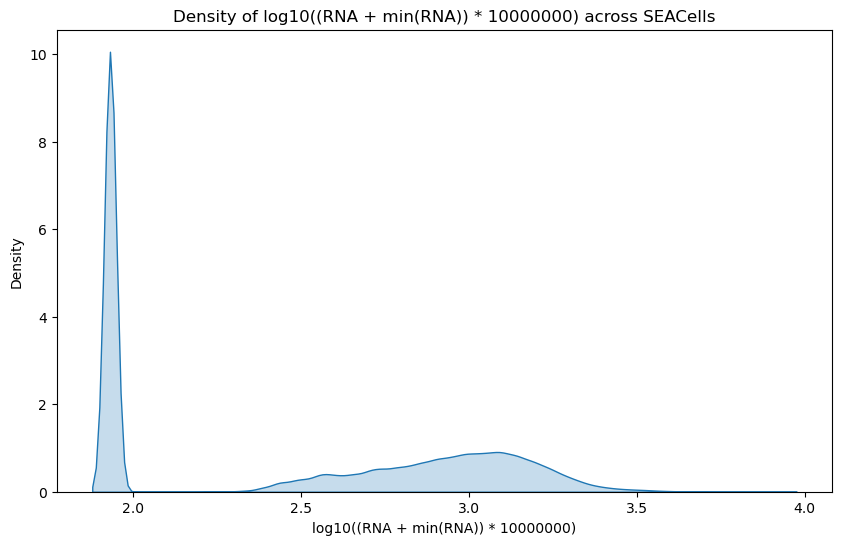

In [17]:
#Plotting the distribution of the value of the genes across all cell types in a boxplot for RNA data
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

P_rna_scaled = np.log10((sc_rna_norm.X+ epsilon_rna)*10000000) 

# RNA counts x samples
P_rna_scaled = P_rna_scaled.T.astype(float)

# convert to long format for seaborn
P_rna_scaled_plot = pd.DataFrame(P_rna_scaled, columns=sc_rna_norm.obs_names).melt(
	var_name="SEACell",
	value_name="log_cpm"
)

#Plotting the distribution of values (log_cpm) of the genes across all SEACells in a density plot for RNA data
plt.figure(figsize=(10, 6))
sns.kdeplot(data=P_rna_scaled_plot, x="log_cpm", fill=True)
plt.title("Density of log10((RNA + min(RNA)) * 10000000) across SEACells")
plt.xlabel("log10((RNA + min(RNA)) * 10000000)")
plt.ylabel("Density")
plt.show()


In [18]:
#taking the minimum non-zero value in the sc_atac_norm matrix to add it to all values before log transformation to avoid taking log of zero
non_zero_mask = (sc_atac_norm.X > 0)
epsilon_at= np.min(sc_atac_norm.X[non_zero_mask])

In [ ]:
#Plotting the distribution of the value of the genes across all cell types in a boxplot for ATAC data
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

P_atac_scaled = np.log10((sc_atac_norm.X+ epsilon_at)*10000000) 

# RNA counts x samples
P_atac_scaled = P_atac_scaled.T.astype(float)

# convert to long format for seaborn
P_atac_scaled_plot = pd.DataFrame(P_atac_scaled, columns=sc_atac_norm.obs_names).melt(
	var_name="SEACell",
	value_name="log_cpm"
)

#Plotting the distribution of values (log_cpm) of the genes across all SEACells in a density plot for ATAC data
plt.figure(figsize=(10, 6))
sns.kdeplot(data=P_atac_scaled_plot, x="log_cpm", fill=True)
plt.title("Density of log10((ATAC + min(ATAC)) * 10000000) across SEACells")
plt.xlabel("log10((ATAC + min(ATAC)) * 10000000)")
plt.ylabel("Density")
plt.show()

In [ ]:
# dictionary to save peak-wise correlation results per gene in 20kb window
import ast
import numpy as np
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

# 1. Compute correlations 
gene_peak_20kb_cor_results = {}

for gene_id in gene_peaks_20kb["gene_id"]:
    assigned_peaks_raw = gene_peaks_20kb.loc[
        gene_peaks_20kb["gene_id"] == gene_id, "assigned_peaks"
    ].iloc[0]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = assigned_peaks_raw

    assigned_peaks = [p for p in assigned_peaks if p in sc_atac_norm.var_names]

    peak_corrs = {}
    if len(assigned_peaks) == 0:
        gene_peak_20kb_cor_results[gene_id] = peak_corrs
        continue

    gene_expression = np.asarray(sc_rna_norm[:, gene_id].X).ravel()

    for peak_id in assigned_peaks:
        peak_accessibility = np.asarray(sc_atac_norm[:, peak_id].X).ravel()

        if np.std(gene_expression) == 0 or np.std(peak_accessibility) == 0:
            peak_corrs[peak_id] = {"corr": np.nan, "pval": np.nan, "padj": np.nan}
        else:
            corr, pval = pearsonr(gene_expression, peak_accessibility)
            peak_corrs[peak_id] = {"corr": corr, "pval": pval, "padj": np.nan}  # padj filled below

    gene_peak_20kb_cor_results[gene_id] = peak_corrs


#2. Collect all valid p-values across every peak–gene pair 
pair_index = []   # keeps track of (gene_id, peak_id) so we can write padj back
pvals_all  = []

for gene_id, peak_corrs in gene_peak_20kb_cor_results.items():
    for peak_id, stats in peak_corrs.items():
        if not np.isnan(stats["pval"]):          # skip NaN (constant vectors)
            pair_index.append((gene_id, peak_id))
            pvals_all.append(stats["pval"])


# 3. Apply Benjamini-Hochberg FDR correction 
if len(pvals_all) > 0:
    _, padj_all, _, _ = multipletests(pvals_all, method="fdr_bh")

    # write adjusted p-values back into the results dictionary
    for (gene_id, peak_id), padj in zip(pair_index, padj_all):
        gene_peak_20kb_cor_results[gene_id][peak_id]["padj"] = padj

In [ ]:
# dictionary to save peak-wise correlation results per gene in 50kb window
import ast
import numpy as np
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

# 1. Compute correlations 
gene_peak_50kb_cor_results = {}

for gene_id in gene_peaks_50kb["gene_id"]:
    assigned_peaks_raw = gene_peaks_50kb.loc[
        gene_peaks_50kb["gene_id"] == gene_id, "assigned_peaks"
    ].iloc[0]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = assigned_peaks_raw

    assigned_peaks = [p for p in assigned_peaks if p in sc_atac_norm.var_names]

    peak_corrs = {}
    if len(assigned_peaks) == 0:
        gene_peak_50kb_cor_results[gene_id] = peak_corrs
        continue

    gene_expression = np.asarray(sc_rna_norm[:, gene_id].X).ravel()

    for peak_id in assigned_peaks:
        peak_accessibility = np.asarray(sc_atac_norm[:, peak_id].X).ravel()

        if np.std(gene_expression) == 0 or np.std(peak_accessibility) == 0:
            peak_corrs[peak_id] = {"corr": np.nan, "pval": np.nan, "padj": np.nan}
        else:
            corr, pval = pearsonr(gene_expression, peak_accessibility)
            peak_corrs[peak_id] = {"corr": corr, "pval": pval, "padj": np.nan}  # padj filled below

    gene_peak_50kb_cor_results[gene_id] = peak_corrs


#2. Collect all valid p-values across every peak–gene pair 
pair_index = []   # keeps track of (gene_id, peak_id) so we can write padj back
pvals_all  = []

for gene_id, peak_corrs in gene_peak_50kb_cor_results.items():
    for peak_id, stats in peak_corrs.items():
        if not np.isnan(stats["pval"]):          # skip NaN (constant vectors)
            pair_index.append((gene_id, peak_id))
            pvals_all.append(stats["pval"])


# 3. Apply Benjamini-Hochberg FDR correction 
if len(pvals_all) > 0:
    _, padj_all, _, _ = multipletests(pvals_all, method="fdr_bh")

    # write adjusted p-values back into the results dictionary
    for (gene_id, peak_id), padj in zip(pair_index, padj_all):
        gene_peak_50kb_cor_results[gene_id][peak_id]["padj"] = padj

In [ ]:
# dictionary to save peak-wise correlation results per gene in 100kb window
import ast
import numpy as np
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

# 1. Compute correlations 
gene_peak_100kb_cor_results = {}

for gene_id in gene_peaks_100kb["gene_id"]:
    assigned_peaks_raw = gene_peaks_100kb.loc[
        gene_peaks_100kb["gene_id"] == gene_id, "assigned_peaks"
    ].iloc[0]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = assigned_peaks_raw

    assigned_peaks = [p for p in assigned_peaks if p in sc_atac_norm.var_names]

    peak_corrs = {}
    if len(assigned_peaks) == 0:
        gene_peak_100kb_cor_results[gene_id] = peak_corrs
        continue

    gene_expression = np.asarray(sc_rna_norm[:, gene_id].X).ravel()

    for peak_id in assigned_peaks:
        peak_accessibility = np.asarray(sc_atac_norm[:, peak_id].X).ravel()

        if np.std(gene_expression) == 0 or np.std(peak_accessibility) == 0:
            peak_corrs[peak_id] = {"corr": np.nan, "pval": np.nan, "padj": np.nan}
        else:
            corr, pval = pearsonr(gene_expression, peak_accessibility)
            peak_corrs[peak_id] = {"corr": corr, "pval": pval, "padj": np.nan}  # padj filled below

    gene_peak_100kb_cor_results[gene_id] = peak_corrs


#2. Collect all valid p-values across every peak–gene pair 
pair_index = []   # keeps track of (gene_id, peak_id) so we can write padj back
pvals_all  = []

for gene_id, peak_corrs in gene_peak_100kb_cor_results.items():
    for peak_id, stats in peak_corrs.items():
        if not np.isnan(stats["pval"]):          # skip NaN (constant vectors)
            pair_index.append((gene_id, peak_id))
            pvals_all.append(stats["pval"])


# 3. Apply Benjamini-Hochberg FDR correction 
if len(pvals_all) > 0:
    _, padj_all, _, _ = multipletests(pvals_all, method="fdr_bh")

    # write adjusted p-values back into the results dictionary
    for (gene_id, peak_id), padj in zip(pair_index, padj_all):
        gene_peak_100kb_cor_results[gene_id][peak_id]["padj"] = padj

In [ ]:
# sanity check: print the shape of the gene expression vector for one gene and the accessibility vector for one peak assigned to that gene
for gene_id in gene_peaks_20kb["gene_id"]:
    assigned_peaks_raw = gene_peaks_20kb.loc[
        gene_peaks_20kb["gene_id"] == gene_id, "assigned_peaks"
    ].iloc[0]
x = sc_rna_norm[:, gene_id].X
print(x.shape)

In [ ]:
# Build one tidy table across all windows and save as CSV for downstream analysis
import numpy as np
import pandas as pd

window_assignments = {
    "10kb":  gene_peak_10kb_cor_results,
    "20kb":  gene_peak_20kb_cor_results,
    "50kb":  gene_peak_50kb_cor_results,
    "100kb": gene_peak_100kb_cor_results,
}

all_window_results = []

for window_label, cor_results in window_assignments.items():
    for gene, peaks in cor_results.items():
        for peak, stats in peaks.items():

            # guard: skip NaN entries (constant vectors)
            if not isinstance(stats, dict):
                continue

            corr = stats.get("corr", np.nan)
            pval = stats.get("pval", np.nan)
            padj = stats.get("padj", np.nan)

            # keep only rows with finite, valid values
            if np.isfinite(corr) and np.isfinite(pval) and 0 < pval <= 1:
                all_window_results.append(
                    {
                        "window":           window_label,
                        "gene":             gene,
                        "peak":             peak,
                        "correlation":      corr,
                        "pvalue":           pval,
                        "neglog10_pvalue":  -np.log10(pval),
                        "padj":             padj,
                        "neglog10_padj":    -np.log10(padj) if np.isfinite(padj) and padj > 0 else np.nan,
                    }
                )

cor_res_df = pd.DataFrame(all_window_results)

# make window an ordered categorical for correct plot ordering
cor_res_df["window"] = pd.Categorical(
    cor_res_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True
)

#save the correlation results as a csv file
cor_res_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_correlation_sc_results.csv", index=False)
print(cor_res_df.shape)
print(cor_res_df.head())